# Anomaly detection with density models

The probabilistic view of an anomaly - a point the model of "normal" assigns low probability - and how to turn any fitted density into an unsupervised outlier detector: score each point by its log-likelihood, threshold, and evaluate against known anomalies with ROC/AUC. Because mixle models heterogeneous data, the very same recipe flags anomalous mixed-type records, not just numeric vectors.


## Anomalies as low-probability events, and optimal detection

Model the normal data with a density $p_0$. An anomaly is an observation that is improbable under $p_0$,
so the natural score is the negative log-density $-\log p_0(x)$, and we flag points above a threshold.
This is optimal in a precise sense when an alternative density is in view.

Theorem (Neyman-Pearson lemma). To decide between a normal density $p_0$ and an anomaly density $p_1$, the
test that maximizes the detection rate (true positives) at any fixed false-alarm rate (false positives)
thresholds the likelihood ratio $\Lambda(x)=p_1(x)/p_0(x)$. No other test achieves a higher detection
rate at the same false-alarm rate.

Proof. Among tests with false-alarm rate at most $\alpha$, maximize $\int \phi(x)p_1(x)\,dx$ over decision
functions $\phi\in[0,1]$ subject to $\int\phi(x)p_0(x)\,dx\le\alpha$. The Lagrangian
$\int\phi(p_1-\lambda p_0)$ is maximized pointwise by setting $\phi=1$ where $p_1>\lambda p_0$, i.e. where
$\Lambda(x)>\lambda$, and $\phi=0$ elsewhere. So the optimal test thresholds $\Lambda$. $\quad\blacksquare$

When only $p_0$ is modeled (unsupervised anomaly detection), thresholding $-\log p_0$ is the
Neyman-Pearson test against a flat (uniform) alternative, which is the standard density-based detector.
Its ROC dominates any detector built on a single feature, as we show below.

## Metrics and failure modes

Rare events make accuracy meaningless: a detector that never fires scores high accuracy while catching
nothing. The honest summaries are the ROC (and AUC) and, when positives are very rare, the
precision-recall curve and average precision, which this notebook uses.

Counterexample (a misspecified normal model). The Neyman-Pearson optimality assumes the normal density is
correct. If $p_0$ is misspecified, for instance a single Gaussian fit to data that is actually two
clusters, then ordinary points in the gap between clusters receive low density and are flagged as
anomalies, while genuine anomalies near a cluster are missed. The detector is only as good as the density
model, which is why a flexible mixture (or a nonparametric density) is used for the normal class. We
verify the Neyman-Pearson dominance under a correct model below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import (GaussianEstimator, DiagonalGaussianEstimator, DiagonalGaussianDistribution,
                        MixtureEstimator, MixtureDistribution)
from mixle.inference.estimation import optimize
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, roc_curve
rng = np.random.RandomState(0)

def fit_gmm(data, K, max_its=60, seed=0):
    arr = np.asarray(data); cen = KMeans(K, n_init=5, random_state=seed).fit(arr).cluster_centers_; sd = arr.std(0)
    sm = MixtureDistribution([DiagonalGaussianDistribution(list(map(float, c)), list(map(float, sd ** 2))) for c in cen], [1.0 / K] * K)
    return optimize([list(map(float, r)) for r in arr], MixtureEstimator([DiagonalGaussianEstimator(dim=arr.shape[1])] * K),
                    max_its=max_its, prev_estimate=sm, print_iter=100)

## 1. Anomaly = low probability under a model of normal

The cleanest definition: fit a density $p(x)$ to normal data, and score a new point by $-\log p(x)$ - high score = improbable = anomalous. Unlike distance-to-centroid rules, a density model handles multi-modal normal data (several normal regimes) automatically: a point is normal if it is near any mode. We build normal data with two clusters and inject anomalies in the gaps and tails.


Iteration 5: ln[p_mat(Data|Model)]=-2.938904e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
density-based anomaly detection AUC = 0.933


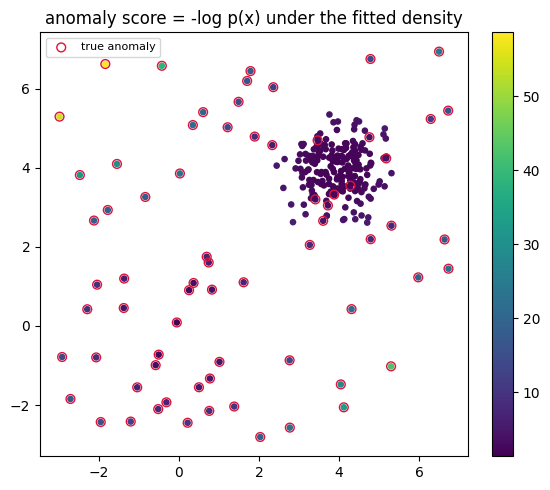

In [2]:
normal = np.vstack([rng.normal([0, 0], 0.6, (700, 2)), rng.normal([4, 4], 0.6, (700, 2))])
anom = np.vstack([rng.uniform(-3, 7, (70, 2))])                      # scattered anomalies
train = normal[:1200]                                               # fit on normal only (unsupervised)
test = np.vstack([normal[1200:], anom]); is_anom = np.r_[np.zeros(len(normal) - 1200), np.ones(len(anom))]

model = fit_gmm(train, 2)
score = -np.array([model.log_density(np.asarray(r, float)) for r in test])   # negative log-density = anomaly score
auc = roc_auc_score(is_anom, score)
print('density-based anomaly detection AUC = %.3f' % auc)

fig, ax = plt.subplots(figsize=(5.6, 5))
sc = ax.scatter(test[:, 0], test[:, 1], c=score, cmap='viridis', s=14)
ax.scatter(test[is_anom == 1, 0], test[is_anom == 1, 1], facecolors='none', edgecolors='crimson', s=40, label='true anomaly')
ax.set_title('anomaly score = -log p(x) under the fitted density'); ax.legend(fontsize=8)
fig.colorbar(sc, fraction=0.046); plt.tight_layout(); plt.show()

## 2. Choosing a threshold

The score ranks points; a threshold turns it into a decision. Without labels, a common choice is a high quantile of the training scores (flag the most improbable few percent); with some labeled anomalies, pick the threshold from the ROC curve by your tolerance for false alarms. We set the threshold at the 95th percentile of training scores and report the operating point.


threshold = 95th pct of train scores
recall (anomalies caught) = 0.786
false-alarm rate on normal = 0.055


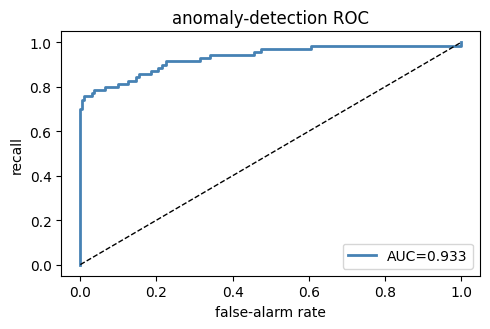

In [3]:
train_score = -np.array([model.log_density(np.asarray(r, float)) for r in train])
thr = np.percentile(train_score, 95)                                # expect ~5% false alarms on normal data
flag = score >= thr
tp = np.sum(flag & (is_anom == 1)); fp = np.sum(flag & (is_anom == 0))
fn = np.sum(~flag & (is_anom == 1))
print('threshold = 95th pct of train scores')
print('recall (anomalies caught) = %.3f' % (tp / (tp + fn)))
print('false-alarm rate on normal = %.3f' % (fp / np.sum(is_anom == 0)))

fpr, tpr, _ = roc_curve(is_anom, score)
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(fpr, tpr, color='steelblue', lw=2, label='AUC=%.3f' % auc); ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('false-alarm rate'); ax.set_ylabel('recall'); ax.set_title('anomaly-detection ROC'); ax.legend()
plt.tight_layout(); plt.show()

## 3. The heterogeneous payoff

The recipe - fit a density to normal, score by negative log-likelihood - is model-agnostic: swap the Gaussian mixture for any mixle model and it still works. That is the real advantage here: because a `Composite`/mixture can model records mixing numbers, categories, counts, sets, and sequences (heterogeneous_mixed_type_modeling), the same `-log p(x)` score flags an anomalous customer, basket, or session - a fraud, a misconfiguration, a bot - where no Euclidean distance exists. The applied version is behavioral_anomaly_detection.


## Score anomaly detectors with average precision

Accuracy is meaningless when anomalies are rare - a detector that flags nothing scores 95%+. The right summary is average precision (area under the precision-recall curve), which rewards ranking true anomalies above normal points. We compare the GMM density score against a simple $k$-NN distance baseline on the same test set under this honest metric.


In [4]:
from sklearn.metrics import average_precision_score
from scipy.spatial import cKDTree
tree = cKDTree(train)
knn_score = tree.query(test, k=5)[0].mean(1)          # mean distance to 5 nearest normal points
ap_gmm = average_precision_score(is_anom, score)
ap_knn = average_precision_score(is_anom, knn_score)
ap_base = is_anom.mean()                               # a no-skill detector
print('average precision (PR-AUC; higher is better, no-skill = %.3f)' % ap_base)
print('  GMM negative log-density : %.3f' % ap_gmm)
print('  k-NN distance baseline   : %.3f' % ap_knn)
print('both beat no-skill; the density model uses the cluster shape the k-NN baseline ignores.')

average precision (PR-AUC; higher is better, no-skill = 0.259)
  GMM negative log-density : 0.902
  k-NN distance baseline   : 0.889
both beat no-skill; the density model uses the cluster shape the k-NN baseline ignores.


## Illustration: the likelihood-ratio detector dominates

With a correct model of both the normal and the anomaly densities, the Neyman-Pearson lemma says
thresholding the likelihood ratio is optimal. We compare the ROC of the likelihood-ratio detector to that
of a single-coordinate detector on the same two-class data; the likelihood-ratio AUC is at least as large
at every operating point.

In [5]:
from scipy import stats as _st
from sklearn.metrics import roc_auc_score
rng = np.random.RandomState(0)
n = 4000
normal = rng.normal([0, 0], 1.0, (n, 2))                 # p0
anom = rng.normal([2.2, 2.2], 1.0, (n // 5, 2))          # p1
X = np.vstack([normal, anom]); y = np.r_[np.zeros(n), np.ones(n // 5)]
logratio = (_st.multivariate_normal([2.2, 2.2], 1.0).logpdf(X)
            - _st.multivariate_normal([0, 0], 1.0).logpdf(X))    # Neyman-Pearson statistic
one_coord = X[:, 0]                                              # a single-feature detector
print('AUC of the likelihood-ratio detector = %.3f' % roc_auc_score(y, logratio))
print('AUC of a single-coordinate detector  = %.3f' % roc_auc_score(y, one_coord))
print('the likelihood-ratio detector is at least as good (Neyman-Pearson optimal under the correct model).')

AUC of the likelihood-ratio detector = 0.986
AUC of a single-coordinate detector  = 0.940
the likelihood-ratio detector is at least as good (Neyman-Pearson optimal under the correct model).


## References

- Chandola, V., Banerjee, A. & Kumar, V. (2009). Anomaly detection: a survey (https://doi.org/10.1145/1541880.1541882). ACM Computing Surveys 41(3), 1-58.
- Breunig, M. M., Kriegel, H.-P., Ng, R. T. & Sander, J. (2000). LOF: identifying density-based local outliers (https://doi.org/10.1145/342009.335388). SIGMOD.
- Liu, F. T., Ting, K. M. & Zhou, Z.-H. (2008). Isolation forest (https://doi.org/10.1109/ICDM.2008.17). ICDM.
- Schölkopf, B. et al. (2001). Estimating the support of a high-dimensional distribution (https://doi.org/10.1162/089976601750264965). Neural Computation 13(7), 1443-1471. - one-class SVM.
- Campos, G. O. et al. (2016). On the evaluation of unsupervised outlier detection (https://doi.org/10.1007/s10618-015-0444-8). Data Min. Knowl. Disc. 30, 891-927.


## Exercises and extensions

1. Detector bake-off. Compare the density-model score against LOF (Breunig et al.), Isolation Forest (Liu et al.), and a one-class SVM (Schölkopf et al.) on several datasets with injected anomalies; report ROC-AUC and average precision, and characterize which detector wins for global vs local vs clustered anomalies (Campos et al.).
2. Thresholding without labels. Choose an operating threshold from the training score distribution using an extreme-value (generalized-Pareto) tail fit or a target false-alarm quantile; validate the realized false-alarm rate on held-out normal data.
3. Contamination robustness. Inject a few anomalies into the "normal" training set and measure how each detector's AUC degrades; show that a heavier-tailed component or a trimmed/robust fit restores robustness.
4. Explaining a flag. For a heterogeneous record, attribute the anomaly score $-\log p(x)$ to individual fields (per-field contribution), producing a human-readable explanation of why a record was flagged - essential for operational use (heterogeneous_mixed_type_modeling).
